In [1]:
from google.colab import files

uploaded = files.upload()

Saving fraud_dataset.csv to fraud_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

In [3]:
df = pd.read_csv('fraud_dataset.csv')

/tmp/ipykernel_763/964491481.py:1: DtypeWarning: Columns (67,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('fraud_dataset.csv')


In [4]:
df.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_verification_status,is_fraud,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.754748,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,...,verified,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.854621,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,...,verified,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.587163,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,...,verified,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244,timothy32,3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3,2825.569899,16:29.9,"Payment to Garcia, Barron and Wood for services",2cc9e843-b5b2-41cf-a6db-aa7fc659986a,89.223.179.179,"(48.549751, -163.02585)",145,...,verified,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,34309820-3aec-4fa4-9518-03437830e1e0,billycalhoun,2e34ad70-ec10-4ac1-895e-2773c6246f62,6509.628443,39:44.7,Payment via link: http://lowe.com/search/wp-co...,b503c1d9-fd00-4289-93b9-e297c98f0228,156.93.45.217,"(-61.0860645, 18.331554)",13,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['transaction_id', 'user_id', 'merchant_id', 'amount', 'timestamp',
       'description', 'device_id', 'ip_address', 'location',
       'session_duration', 'authentication_attempts', 'receiver_account_age',
       'receiver_transaction_history', 'transaction_amount_vs_sender_history',
       'geographic_disparity', 'transaction_time_of_day',
       'merchant_category_code', 'session_source', 'url_referrer',
       'time_between_link_click_and_transaction', 'unusual_device_flag',
       'unusual_ip_flag', 'unusual_location_flag', 'dns_lookup_age',
       'recent_app_installs', 'input_timing_consistency',
       'app_switching_frequency', 'keyboard_input_speed',
       'input_pause_patterns', 'permissions_granted', 'screen_active_time',
       'geographic_location_vs_ip', 'background_data_usage',
       'recognized_screen_sharing_apps', 'authentication_attempt_count',
       'time_between_otp_generation_and_input', 'pin_entry_method',
       'pin_entry_speed', 'unusual_transaction_

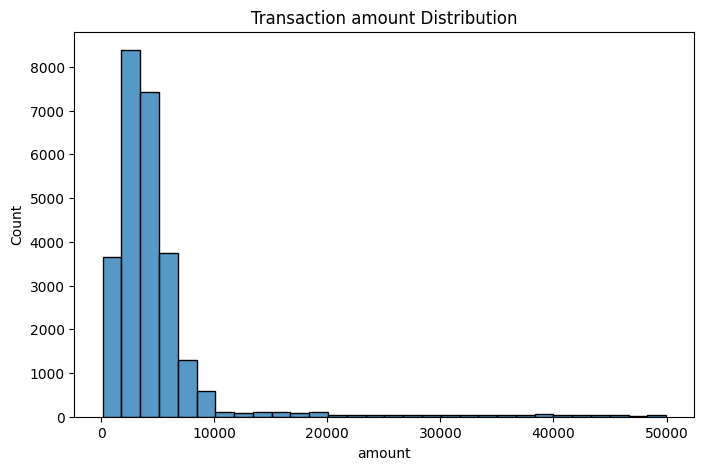

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=30)

plt.title('Transaction amount Distribution')
plt.show()

In [7]:
df['amount'].skew()

np.float64(4.84601471037098)

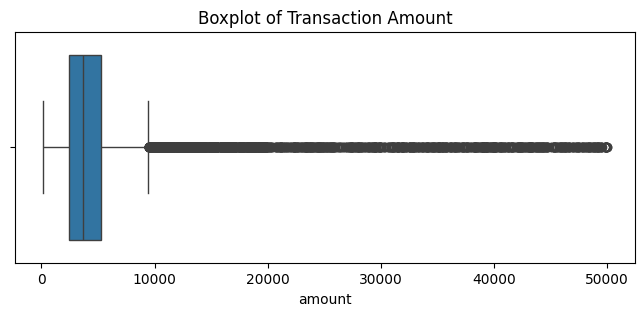

In [8]:
plt.figure(figsize=(8,3))

sns.boxplot(x=df['amount'])

plt.title('Boxplot of Transaction Amount')
plt.show()

In [9]:
Q1 = df['amount'].quantile(0.25)

Q3 = df['amount'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =",Q1)
print("Q3 =",Q3)
print("IQR =",IQR)

Q1 = 2425.484162
Q3 = 5239.994313
IQR = 2814.510151


In [10]:
lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

print("Lower Limit =",lower)
print("Upper Limit =",upper)

Lower Limit = -1796.2810644999995
Upper Limit = 9461.759539499999


In [11]:
iqr_outliers = df[
    (df['amount'] < lower) |
    (df['amount'] > upper)
]

print("Number of Outliers:",len(iqr_outliers))

Number of Outliers: 1477


In [12]:
iqr_outliers.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_verification_status,is_fraud,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72
33,5d7e5028-4347-4a63-8897-299c1ec981de,evanscarol,1cb3e29e-739b-44c7-8341-e9e711795fd5,9723.093184,53:00.8,Payment to Lawso_clone,96e282ac-d653-49e3-a1d4-bf2152a19622,73.237.139.79,"(55.1109865, 63.758942)",159,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,b8b0394b-513e-4432-b12e-eabd56524184,daviskenneth,8ba1a9c1-8f76-42b7-a556-3971aeb8466b,13194.131530,56:55.7,OTP authentication payment,9086d747-af12-47db-a1e8-ca3ac2dadb15,31.217.30.148,"(-48.077449, -61.790369)",90,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,de54c8a9-4bfb-42e0-973e-b64dece128eb,sheila86,19107c8d-f750-4ff7-b090-4c885ed6ef1f,37482.598260,03:40.1,Payment to Paytm_clone for premium products,7c0a3461-f5dc-4c68-9a65-1b8c1a1808a0,3.155.227.121,"(-85.158965, 46.209209)",236,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,35dbb710-6781-4f19-ad55-d2b9022647b6,wadedustin,988a3037-fcc7-4777-92a8-6ed04ca33137,18330.256760,54:28.2,OTP authentication payment,1a664e71-2d81-411d-9a2a-49635a513b5c,167.0.124.120,"(68.457279, 139.796467)",87,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,5d781375-a908-421e-abbb-69c16818a341,nixonmichael,daac4334-629b-44ff-ac6f-af9d0d474918,24931.582370,06:06.6,Payment to Paytm_clone for premium products,a0150ed7-2b3c-4337-a0f1-49500f247921,187.194.94.17,"(-13.428787, -48.794045)",113,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df['Z_Score'] = zscore(df['amount'])

In [14]:
df[['amount','Z_Score']].head()

,amount,Z_Score
0,1960.754748,-0.507764
1,4593.854621,-0.047464
2,1949.587163,-0.509716
3,2825.569899,-0.356583
4,6509.628443,0.287438


In [15]:
z_outliers = df[
    abs(df['Z_Score']) > 3
]

print("Z-score Outliers:",len(z_outliers))

Z-score Outliers: 651


In [16]:
z_outliers.head()

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,is_fraud,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Z_Score
110,de54c8a9-4bfb-42e0-973e-b64dece128eb,sheila86,19107c8d-f750-4ff7-b090-4c885ed6ef1f,37482.59826,03:40.1,Payment to Paytm_clone for premium products,7c0a3461-f5dc-4c68-9a65-1b8c1a1808a0,3.155.227.121,"(-85.158965, 46.209209)",236,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.701914
131,5d781375-a908-421e-abbb-69c16818a341,nixonmichael,daac4334-629b-44ff-ac6f-af9d0d474918,24931.58237,06:06.6,Payment to Paytm_clone for premium products,a0150ed7-2b3c-4337-a0f1-49500f247921,187.194.94.17,"(-13.428787, -48.794045)",113,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.507834
158,40b65b1a-6daf-486b-8e25-758e705140b1,gmarshall,b4c6a617-4d2d-4050-b6e5-5ed9cf7c366e,49146.97023,44:04.6,Payment to Snapdeal_clone for premium products,8b50cfeb-6bb0-4d26-9af9-defb0ba2b9d8,212.251.216.97,"(49.5169695, 86.991916)",294,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.740998
278,0c274fad-bf5f-4ad3-90d3-3a7b64d3b14c,hillsabrina,72266c00-c5ab-4014-b645-122f226b26eb,27708.37172,57:21.2,Payment to Amazon_clone for premium products,b0fb8427-b0a3-4a3e-910d-4d6692cfa6f5,72.6.118.61,"(56.162794, 35.856962)",270,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.993253
406,0cc8042b-0492-437d-a9b6-c3f14319ad76,dennissmith,2a856e5d-58a6-4b1d-a956-08b7101dc1e4,32095.77469,55:43.7,Payment to Paytm_clone for premium products,93c24885-a01e-4068-bc13-45e625525ed0,37.122.221.66,"(73.1810895, 40.122315)",57,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.760228


In [17]:
print("IQR Outliers:",len(iqr_outliers))

print("Z-score Outliers:",len(z_outliers))

IQR Outliers: 1477
Z-score Outliers: 651


In [18]:
iqr_outliers

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,handle_verification_status,is_fraud,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72
33,5d7e5028-4347-4a63-8897-299c1ec981de,evanscarol,1cb3e29e-739b-44c7-8341-e9e711795fd5,9723.093184,53:00.8,Payment to Lawso_clone,96e282ac-d653-49e3-a1d4-bf2152a19622,73.237.139.79,"(55.1109865, 63.758942)",159,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,b8b0394b-513e-4432-b12e-eabd56524184,daviskenneth,8ba1a9c1-8f76-42b7-a556-3971aeb8466b,13194.131530,56:55.7,OTP authentication payment,9086d747-af12-47db-a1e8-ca3ac2dadb15,31.217.30.148,"(-48.077449, -61.790369)",90,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,de54c8a9-4bfb-42e0-973e-b64dece128eb,sheila86,19107c8d-f750-4ff7-b090-4c885ed6ef1f,37482.598260,03:40.1,Payment to Paytm_clone for premium products,7c0a3461-f5dc-4c68-9a65-1b8c1a1808a0,3.155.227.121,"(-85.158965, 46.209209)",236,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,35dbb710-6781-4f19-ad55-d2b9022647b6,wadedustin,988a3037-fcc7-4777-92a8-6ed04ca33137,18330.256760,54:28.2,OTP authentication payment,1a664e71-2d81-411d-9a2a-49635a513b5c,167.0.124.120,"(68.457279, 139.796467)",87,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
131,5d781375-a908-421e-abbb-69c16818a341,nixonmichael,daac4334-629b-44ff-ac6f-af9d0d474918,24931.582370,06:06.6,Payment to Paytm_clone for premium products,a0150ed7-2b3c-4337-a0f1-49500f247921,187.194.94.17,"(-13.428787, -48.794045)",113,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26308,64ff1f63-8add-400d-9716-38a939bc0df8,tpalmer,144449e1-20ff-4af3-9b79-8f34cf96b57b,27982.696960,23:46.8,Payment to Flipkart_clone for premium products,01730e59-f703-4e00-a247-495f5af77492,101.151.111.193,"(80.08691, 171.074642)",67,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26323,c9442c26-b091-4a5b-9cfe-c6964da31c57,georgejay,418b022c-4d8b-4da7-b530-35565408a0d8,16240.292450,06:23.3,OTP authentication payment,6ced365a-7bf7-4e07-95d5-867ce6c29210,128.229.155.170,"(-86.665899, -176.942458)",59,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26324,ea944fed-0342-4bdf-9626-3f923aa680ee,sandra03,2d640bca-0e5a-475d-bf8c-b22c3fe847ff,10520.606020,51:21.4,OTP authentication payment,5e938da8-29b3-4074-ab80-bfa014391fb7,82.22.19.57,"(-55.6703395, 147.39293)",53,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26358,5f871cba-4acb-426a-88f0-df273a195004,zcalhoun,aade38ca-20f5-4d8e-ab42-6690080b998b,42473.121730,13:14.4,Payment to Flipkart_clone for premium products,90bfe6d5-f9a0-473f-ab9e-9fe78fdb6d26,196.126.221.107,"(75.3665, -106.09409)",94,...,unverified,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
from scipy.stats import zscore

df['z_score'] = zscore(df['amount'])

z_outliers = df[abs(df['z_score']) > 3]

print("Number of Z-score outliers:", len(z_outliers))

Number of Z-score outliers: 651


In [20]:
z_outliers[['user_id','amount','z_score','is_fraud']].head(10)

,user_id,amount,z_score,is_fraud
110,sheila86,37482.59826,5.701914,1
131,nixonmichael,24931.58237,3.507834,1
158,gmarshall,49146.97023,7.740998,1
278,hillsabrina,27708.37172,3.993253,1
406,dennissmith,32095.77469,4.760228,1
474,joan49,36418.13555,5.515832,1
478,davisdebra,40119.65013,6.162905,1
515,travisjohnson,48260.37929,7.586010,1
536,qrios,22513.52366,3.085126,1
569,corey12,36818.99902,5.585909,1


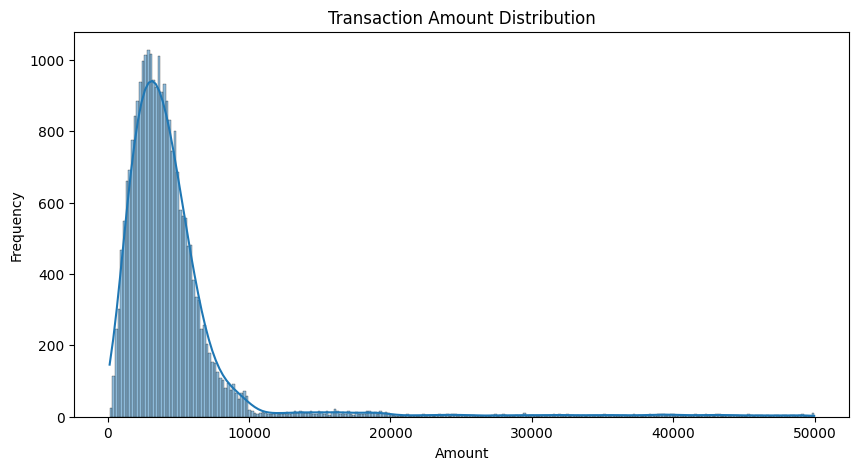

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['amount'], kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [22]:
df.columns.tolist()

['transaction_id',
 'user_id',
 'merchant_id',
 'amount',
 'timestamp',
 'description',
 'device_id',
 'ip_address',
 'location',
 'session_duration',
 'authentication_attempts',
 'receiver_account_age',
 'receiver_transaction_history',
 'transaction_amount_vs_sender_history',
 'geographic_disparity',
 'transaction_time_of_day',
 'merchant_category_code',
 'session_source',
 'url_referrer',
 'time_between_link_click_and_transaction',
 'unusual_device_flag',
 'unusual_ip_flag',
 'unusual_location_flag',
 'dns_lookup_age',
 'recent_app_installs',
 'input_timing_consistency',
 'app_switching_frequency',
 'keyboard_input_speed',
 'input_pause_patterns',
 'permissions_granted',
 'screen_active_time',
 'geographic_location_vs_ip',
 'background_data_usage',
 'recognized_screen_sharing_apps',
 'authentication_attempt_count',
 'time_between_otp_generation_and_input',
 'pin_entry_method',
 'pin_entry_speed',
 'unusual_transaction_amount_flag',
 'otp_request_frequency',
 'otp_request_device_consi

In [23]:
df['request_frequency'].describe() # Unusually Frequent Transactions

,request_frequency
count,26393.000000
mean,0.210889
std,1.279194
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,10.000000


In [24]:
df[df['requester_account_age'] < 30][
    ['user_id','requester_account_age','amount','is_fraud']
].head(10)

,user_id,requester_account_age,amount,is_fraud
0,michelle89,0,1960.754748,0
1,eguerrero,0,4593.854621,0
2,alexanderpatrick,0,1949.587163,0
3,timothy32,0,2825.569899,0
4,billycalhoun,0,6509.628443,1
5,zacharynielsen,0,2370.595249,0
6,hfrye,0,2321.374692,0
7,rogerjohnson,0,2438.345336,0
8,linda77,0,241.684124,0
9,crystal81,0,4982.700905,0


In [25]:
#New Accounts with Abnormal Activity
df[df['requester_account_age']<30]

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Z_Score,z_score
0,7d4e9561-000c-44c8-84e4-54af2c4ac209,michelle89,8bdff36c-efba-4260-a801-8bd36f0f2eb0,1960.754748,18:27.7,Payment to Lee-Warren for products,0c51ef4f-41a8-41da-b721-b74a8055dc4c,49.221.248.16,"(14.5837385, 85.305345)",234,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.507764,-0.507764
1,fbf88cde-dc62-4f36-ac10-a1b1fd771793,eguerrero,a28f2b48-5423-4eb6-9018-00e6e55410af,4593.854621,34:55.5,"Payment to Wright, Johnson and Parker for prod...",932aab8b-af95-4214-b555-7f5f2d67308c,106.79.40.40,"(-41.063726, -164.178102)",98,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.047464,-0.047464
2,d746c963-baaa-46a0-80f4-b050e14e1c7d,alexanderpatrick,ce4ed336-6b99-42f2-88ca-dba320b8a96f,1949.587163,49:42.8,Payment to Hanson Ltd for products,0dc46fa1-fb1f-4bc6-9e03-af19e1c46e1b,125.165.248.30,"(52.1582705, -162.522989)",100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.509716,-0.509716
3,e5f8a1cc-4bf6-46d2-b9b2-aa393ff4e244,timothy32,3a6129b8-6cdd-4c5a-9bf5-a312da5a9fd3,2825.569899,16:29.9,"Payment to Garcia, Barron and Wood for services",2cc9e843-b5b2-41cf-a6db-aa7fc659986a,89.223.179.179,"(48.549751, -163.02585)",145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.356583,-0.356583
4,34309820-3aec-4fa4-9518-03437830e1e0,billycalhoun,2e34ad70-ec10-4ac1-895e-2773c6246f62,6509.628443,39:44.7,Payment via link: http://lowe.com/search/wp-co...,b503c1d9-fd00-4289-93b9-e297c98f0228,156.93.45.217,"(-61.0860645, 18.331554)",13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.287438,0.287438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26388,a9fcaaa8-87f6-4f9e-9a28-6e10928970d9,ucarter,a52c438a-da05-494b-a140-efaccdeef2a5,2990.065603,19:52.2,Payment to Ryan-Lee for products,8bd681b9-27c6-43f0-a09f-d26f1f8b6ced,12.152.136.104,"(63.930842, 10.487879)",177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.327827,-0.327827
26389,5034b135-5795-4ae6-ada3-81dd1754e72e,tjohnson,99c932d9-b68b-4975-a39a-b68402990d5d,6602.319359,18:56.8,Payment to Fuller-Owens for services,07a2bc3b-31e7-460a-bc88-91b009e15dbd,158.31.212.173,"(81.9241255, -18.696792)",63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.303642,0.303642
26390,0a9256ed-66d6-4a68-a571-1ad8752b84e0,joshuaharris,048b1a2d-987d-4dfa-b68d-17f3bc09a215,28923.658050,07:22.6,Payment to Paytm_clone for premium products,a0697f2e-8321-41dc-9582-fc856802323f,39.14.156.82,"(-49.8408755, -63.869035)",259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.205701,4.205701
26391,f683c6fa-da49-439a-95e0-b272bda08724,mcline,06e41f77-d51d-4522-be8e-71a79083fe11,2279.373776,32:37.4,Payment to Smith and Sons for services,8d846731-fece-4837-950d-cac5c2951ebe,8.37.224.40,"(-47.1112205, -146.444328)",124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.452065,-0.452065


In [26]:
iqr_outliers['amount'].sort_values(ascending=False).head(10)

,amount
20216,49970.15858
5647,49964.03401
20279,49954.06048
23415,49922.96930
25969,49915.98148
11811,49912.17616
22951,49901.61934
17534,49867.01355
17768,49848.14218
21391,49844.67746


In [27]:
df['transaction_velocity'].describe()
df.sort_values('transaction_velocity', ascending=False)[['user_id','transaction_velocity']].head(10)

,user_id,transaction_velocity
16341,blopez,5
14617,monicacopeland,5
15943,morganjames,5
16877,williamtorres,5
24921,jacob86,5
1682,jeffery07,5
16563,andrea66,5
3447,jensenmichael,5
17604,laurie31,5
2430,danieljones,5


In [28]:
df.sort_values('requester_account_age').head(10)
df[['requester_account_age','amount']].sort_values('requester_account_age').head(20)

,requester_account_age,amount
17487,0,2261.816146
17500,0,3053.509863
17499,0,4534.581867
17498,0,3375.256454
17497,0,1870.615504
17496,0,4723.034020
17494,0,4284.521213
17493,0,2812.267556
17492,0,4743.630883
17491,0,1391.410819


In [30]:
z_outliers

,transaction_id,user_id,merchant_id,amount,timestamp,description,device_id,ip_address,location,session_duration,...,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Z_Score,z_score
110,de54c8a9-4bfb-42e0-973e-b64dece128eb,sheila86,19107c8d-f750-4ff7-b090-4c885ed6ef1f,37482.59826,03:40.1,Payment to Paytm_clone for premium products,7c0a3461-f5dc-4c68-9a65-1b8c1a1808a0,3.155.227.121,"(-85.158965, 46.209209)",236,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.701914,5.701914
131,5d781375-a908-421e-abbb-69c16818a341,nixonmichael,daac4334-629b-44ff-ac6f-af9d0d474918,24931.58237,06:06.6,Payment to Paytm_clone for premium products,a0150ed7-2b3c-4337-a0f1-49500f247921,187.194.94.17,"(-13.428787, -48.794045)",113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.507834,3.507834
158,40b65b1a-6daf-486b-8e25-758e705140b1,gmarshall,b4c6a617-4d2d-4050-b6e5-5ed9cf7c366e,49146.97023,44:04.6,Payment to Snapdeal_clone for premium products,8b50cfeb-6bb0-4d26-9af9-defb0ba2b9d8,212.251.216.97,"(49.5169695, 86.991916)",294,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.740998,7.740998
278,0c274fad-bf5f-4ad3-90d3-3a7b64d3b14c,hillsabrina,72266c00-c5ab-4014-b645-122f226b26eb,27708.37172,57:21.2,Payment to Amazon_clone for premium products,b0fb8427-b0a3-4a3e-910d-4d6692cfa6f5,72.6.118.61,"(56.162794, 35.856962)",270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.993253,3.993253
406,0cc8042b-0492-437d-a9b6-c3f14319ad76,dennissmith,2a856e5d-58a6-4b1d-a956-08b7101dc1e4,32095.77469,55:43.7,Payment to Paytm_clone for premium products,93c24885-a01e-4068-bc13-45e625525ed0,37.122.221.66,"(73.1810895, 40.122315)",57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.760228,4.760228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26182,2f8f0a2f-09f7-46fa-a28b-85531e9bb1d7,leslie49,f67678f5-e917-498e-bbfd-00eb519905f3,27293.80611,29:48.0,Payment to Amazon_clone for premium products,2da19f68-3588-473f-a1fe-a1e0d49340ff,128.155.124.72,"(-29.0794375, 179.715309)",36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.920782,3.920782
26280,b4424b23-2568-453a-b65a-fc70c6502fde,ryan33,2674ddc7-81d1-411d-884d-be96445969a4,34508.90409,15:41.1,Payment to Flipkart_clone for premium products,42ff750f-d450-45c5-9a36-1f8ef53108a3,38.157.189.79,"(-11.1880775, -68.348019)",244,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.182074,5.182074
26308,64ff1f63-8add-400d-9716-38a939bc0df8,tpalmer,144449e1-20ff-4af3-9b79-8f34cf96b57b,27982.69696,23:46.8,Payment to Flipkart_clone for premium products,01730e59-f703-4e00-a247-495f5af77492,101.151.111.193,"(80.08691, 171.074642)",67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.041209,4.041209
26358,5f871cba-4acb-426a-88f0-df273a195004,zcalhoun,aade38ca-20f5-4d8e-ab42-6690080b998b,42473.12173,13:14.4,Payment to Flipkart_clone for premium products,90bfe6d5-f9a0-473f-ab9e-9fe78fdb6d26,196.126.221.107,"(75.3665, -106.09409)",94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.574322,6.574322


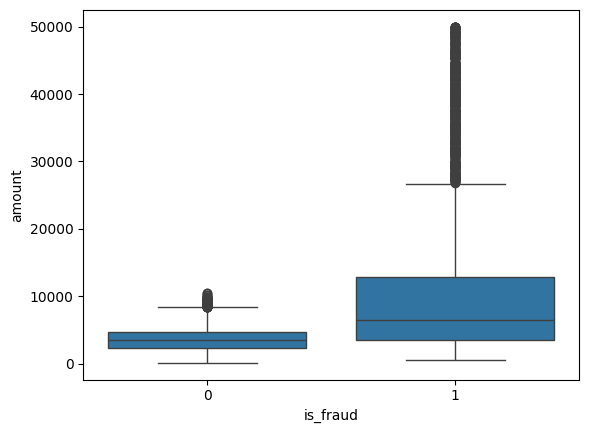

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create the 'images' directory if it doesn't exist
if not os.path.exists('../images'):
    os.makedirs('../images')

sns.boxplot(x='is_fraud', y='amount', data=df)
plt.savefig("../images/ps4_transaction_amt_vs_fraud.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [33]:
#Time of Day vs Fraud
pd.crosstab(
    df['transaction_time_of_day'],
    df['is_fraud']
)

is_fraud,0,1
transaction_time_of_day,,
0,881,231
1,918,283
2,908,306
3,956,373
4,897,360
5,903,492
6,983,659
7,913,338
8,916,5


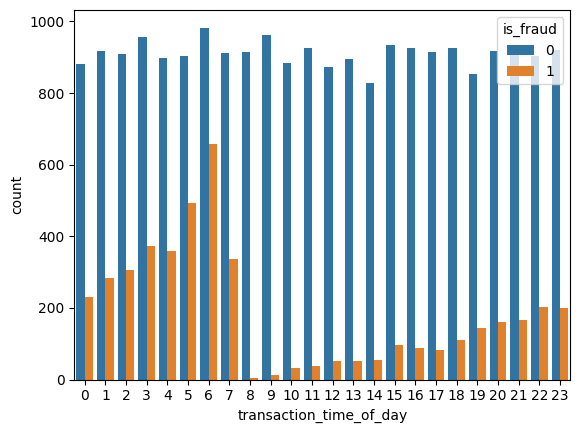

In [34]:
#Visualization:
sns.countplot(
    x='transaction_time_of_day',
    hue='is_fraud',
    data=df
)
plt.savefig("../images/timeofday_vs_fraud.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [35]:
#Device Changes vs Fraud use column unusual_device_flag
pd.crosstab(
    df['unusual_device_flag'],
    df['is_fraud']
)

is_fraud,0,1
unusual_device_flag,,
0,21848,3055
1,0,1490


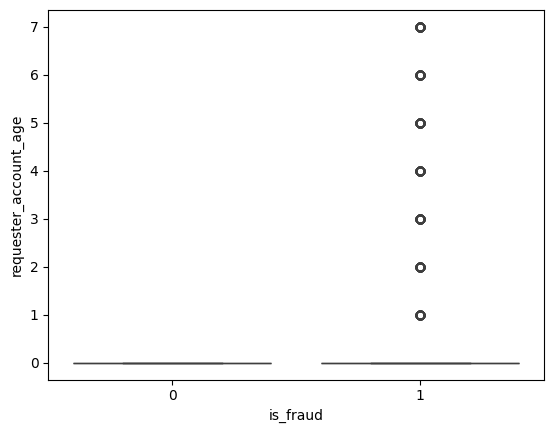

In [36]:
#. Account Age vs Fraud use column requester_account_age
sns.boxplot(
    x='is_fraud',
    y='requester_account_age',
    data=df
)
plt.savefig("../images/accountage_vs_fraud.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

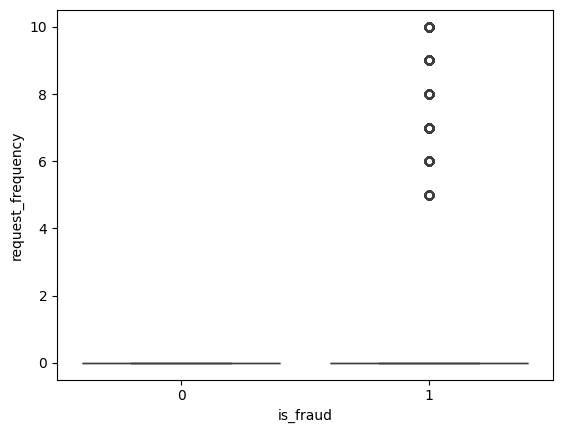

In [37]:
#Frequency vs Fraud use request_frequency

sns.boxplot(
    x='is_fraud',
    y='request_frequency',
    data=df
)
plt.savefig("../images/frequency_vs_fraud.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

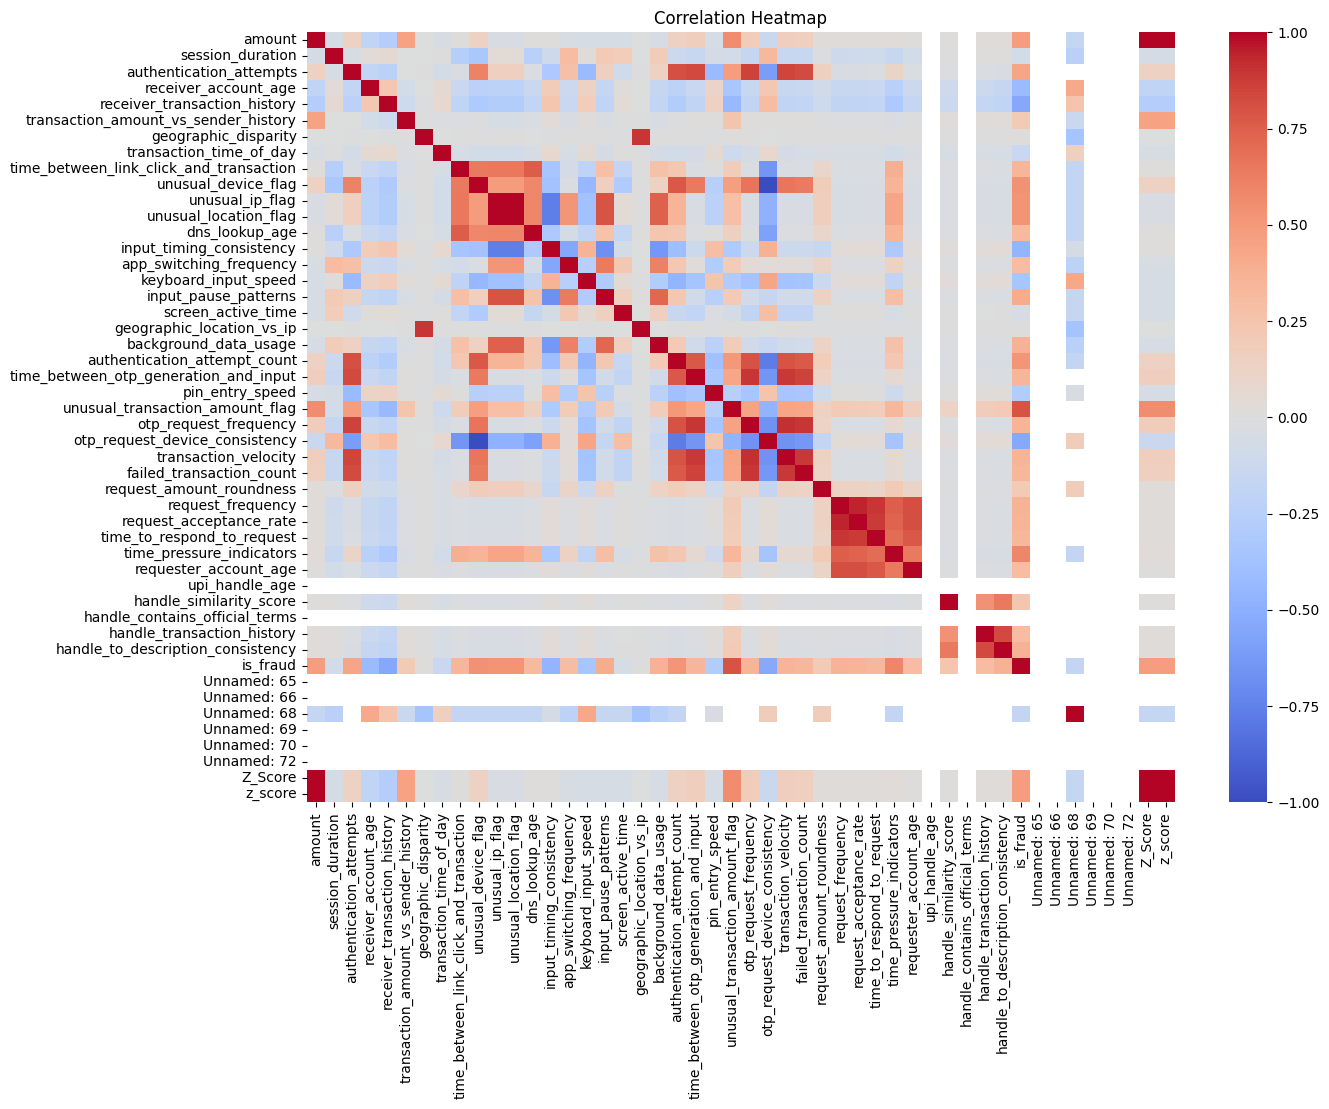

In [38]:
#Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.savefig("../images/heatmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

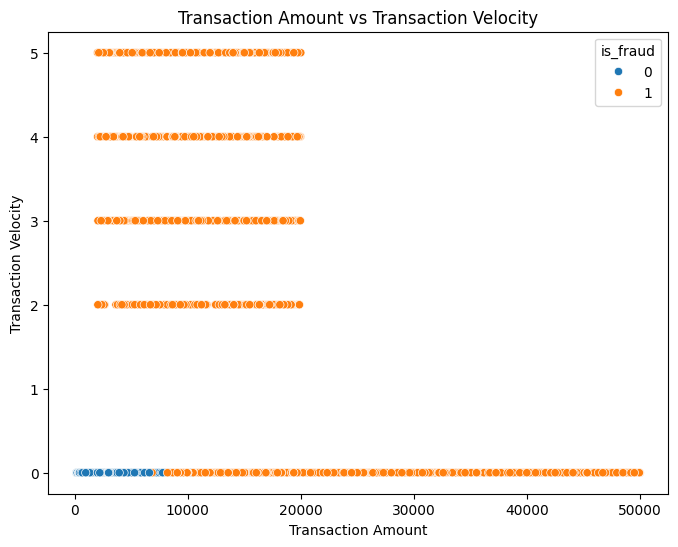

In [39]:
#Scatter Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='amount',
    y='transaction_velocity',
    hue='is_fraud'
)

plt.title("Transaction Amount vs Transaction Velocity")
plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Velocity")
plt.savefig("../images/sactter_plot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

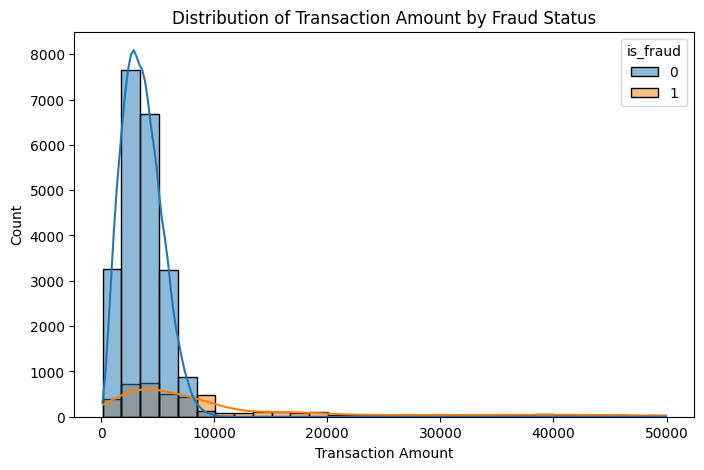

In [40]:
#Histogram (
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='amount',
    hue='is_fraud',
    kde=True,
    bins=30
)

plt.title("Distribution of Transaction Amount by Fraud Status")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.savefig("../images/histogram.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [41]:
#Import Library
from scipy.stats import ttest_ind

In [43]:
#Separate the Data
fraud = df[df['is_fraud'] == 1]['amount']
non_fraud = df[df['is_fraud'] == 0]['amount']

In [44]:
#Perform the T-Test
t_stat, p_value = ttest_ind(fraud, non_fraud)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 88.21175558879828
P-Value: 0.0


In [45]:
#Decision
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("Transaction amount has a significant relationship with fraud.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("Transaction amount has no significant relationship with fraud.")

Reject the Null Hypothesis (H₀)
Transaction amount has a significant relationship with fraud.


In [46]:
#phase:6 Statistical Fraud Signals

In [47]:
fraud_signal_report = pd.DataFrame({
    "Fraud Signal": [
        "High Transaction Amount",
        "Rapid Transaction Bursts",
        "Unusual Device Usage",
        "Late-Night Transaction Activity",
        "New Accounts Making Large Payments"
    ],
    "Severity": [
        "Very High",
        "High",
        "Very High",
        "Medium",
        "High"
    ]
})

fraud_signal_report

,Fraud Signal,Severity
0,High Transaction Amount,Very High
1,Rapid Transaction Bursts,High
2,Unusual Device Usage,Very High
3,Late-Night Transaction Activity,Medium
4,New Accounts Making Large Payments,High


In [48]:
#Phase 7: Business Insights

In [49]:
#Q1. Which variables strongly indicate fraud?
#Code 1: Fraud Rate Analysis

In [50]:
# Variables to analyze

fraud_variables = [
    "unusual_device_flag",
    "unusual_ip_flag",
    "unusual_location_flag",
    "unusual_transaction_amount_flag"
]

for col in fraud_variables:
    print("="*60)
    print(f"Fraud Rate based on {col}")
    print((df.groupby(col)["is_fraud"].mean()*100).round(2))

Fraud Rate based on unusual_device_flag
unusual_device_flag
0     12.27
1    100.00
Name: is_fraud, dtype: float64
Fraud Rate based on unusual_ip_flag
unusual_ip_flag
0     12.41
1    100.00
Name: is_fraud, dtype: float64
Fraud Rate based on unusual_location_flag
unusual_location_flag
0     12.41
1    100.00
Name: is_fraud, dtype: float64
Fraud Rate based on unusual_transaction_amount_flag
unusual_transaction_amount_flag
0      6.36
1    100.00
Name: is_fraud, dtype: float64


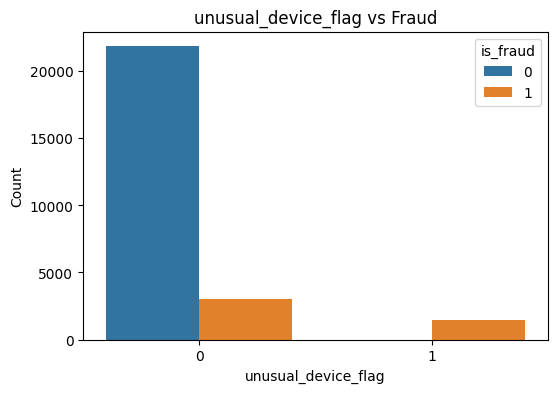

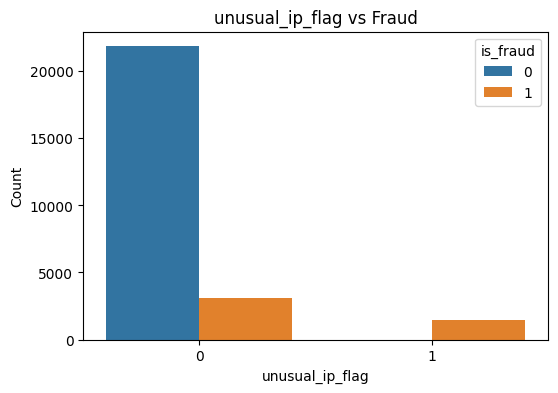

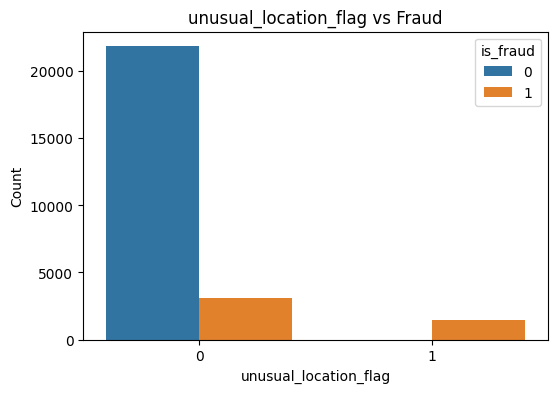

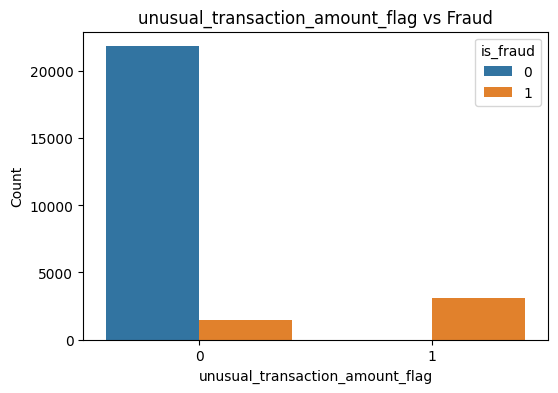

In [51]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

for col in fraud_variables:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="is_fraud")
    plt.title(f"{col} vs Fraud")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.savefig("../images/phase7Q1.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

In [55]:
#Q2. Are high-value transactions always risky?


In [56]:
df.groupby("is_fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,21848.0,3620.345820,1714.887881,139.267664,2319.348632,3460.913626,4764.267109,10523.91020
1,4545.0,10850.235157,11517.240180,519.437400,3519.155373,6482.957050,12817.819080,49970.15858


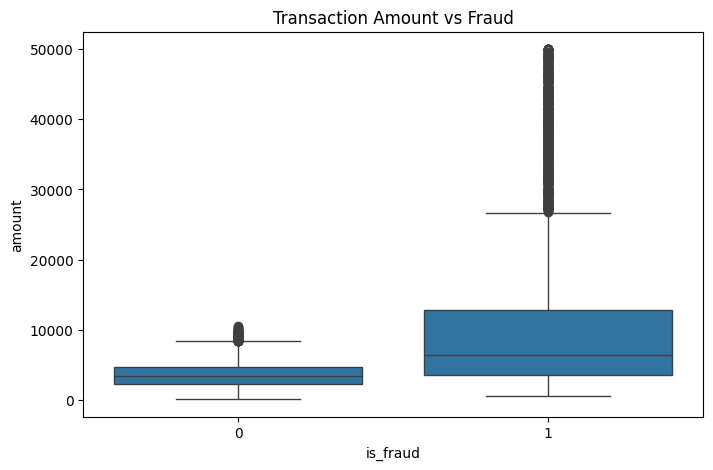

In [57]:
#Visualization
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount"
)

plt.title("Transaction Amount vs Fraud")
plt.savefig("../images/phase7q2_arehighvalue.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [58]:
#Q3. What user behaviors appear suspicious?
behavior_columns = [
    "transaction_velocity",
    "failed_transaction_count",
    "otp_request_frequency"
]

df.groupby("is_fraud")[behavior_columns].mean().round(2)

,transaction_velocity,failed_transaction_count,otp_request_frequency
is_fraud,,,
0,0.00,0.00,0.00
1,0.56,0.33,0.48


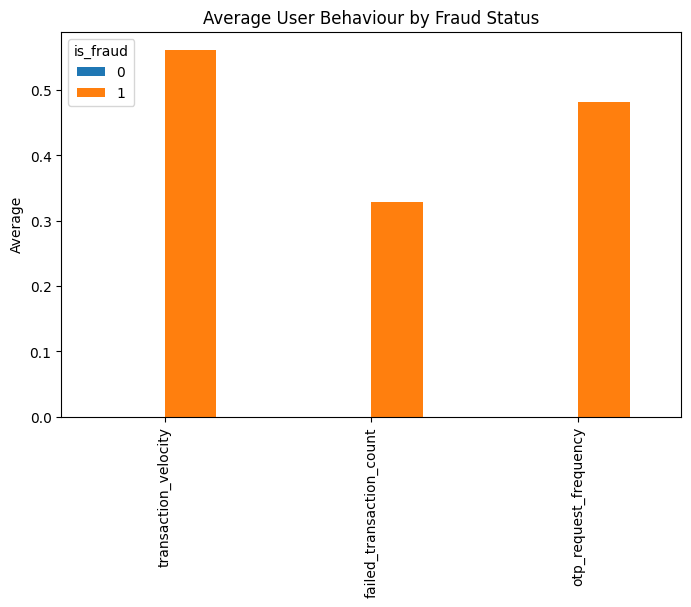

In [59]:
#Visualization
behavior_mean = df.groupby("is_fraud")[behavior_columns].mean()

behavior_mean.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average User Behaviour by Fraud Status")
plt.ylabel("Average")
plt.savefig("../images/phase7Q3.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [60]:
#Q4. Which customer segments require monitoring?
# Fraud rate by receiver account age

account_age_fraud = (
    df.groupby("receiver_account_age")["is_fraud"]
      .mean()
      .sort_values(ascending=False) * 100
)

print(account_age_fraud.round(2))

receiver_account_age
0      93.81
462     0.00
463     0.00
464     0.00
465     0.00
       ...  
237     0.00
238     0.00
239     0.00
240     0.00
230     0.00
Name: is_fraud, Length: 703, dtype: float64


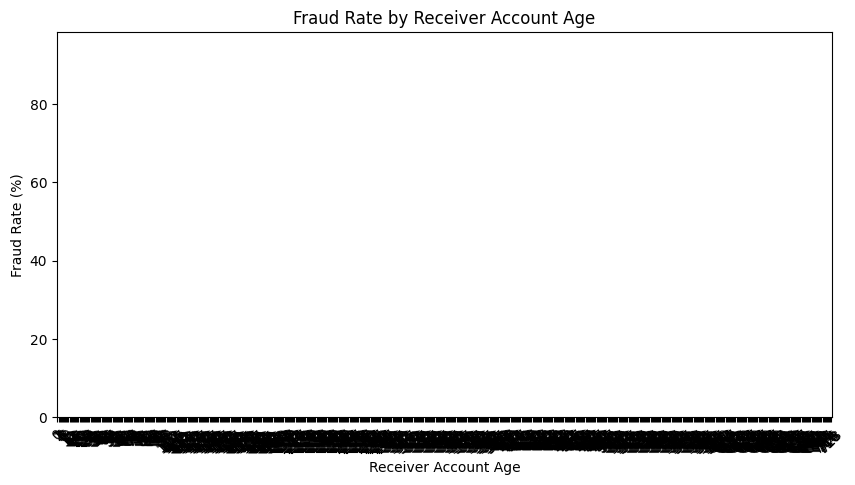

In [61]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=account_age_fraud.index,
    y=account_age_fraud.values
)

plt.title("Fraud Rate by Receiver Account Age")
plt.xlabel("Receiver Account Age")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.savefig("../images/phase7Q4.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [62]:
#Q5. What recommendations would you provide to fraud teams?
#Step 1: Summary Statistics (Python)
# Summary Statistics

total_transactions = len(df)
fraud_transactions = df["is_fraud"].sum()
fraud_percentage = (fraud_transactions / total_transactions) * 100

print("========== Fraud Summary ==========")
print(f"Total Transactions      : {total_transactions}")
print(f"Fraud Transactions      : {fraud_transactions}")
print(f"Fraud Percentage (%)    : {fraud_percentage:.2f}")

========== Fraud Summary ==========
Total Transactions      : 26393
Fraud Transactions      : 4545
Fraud Percentage (%)    : 17.22
